In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.objective_functions import portfolio_variance

In [53]:
general_portfolio = pd.read_csv("../data_financialcrisis/crisis_portfolio.csv")

general_portfolio.Date = pd.to_datetime(general_portfolio.Date)
general_portfolio.set_index("Date", inplace=True)

/var/folders/2h/8jbngzys5690t1qxbcx36brh0000gn/T/ipykernel_66317/1506557499.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  general_portfolio.Date = pd.to_datetime(general_portfolio.Date)


In [54]:
#general_portfolio.head(5)

In [55]:
returns = general_portfolio.pct_change().dropna()

In [56]:
#returns.head()

In [57]:
returns.cov()

,Citibank,Morgan Stanley,Goldman Sachs,J.P. Morgan
Citibank,0.002128,0.001210,0.000865,0.001071
Morgan Stanley,0.001210,0.001952,0.001026,0.000866
Goldman Sachs,0.000865,0.001026,0.000864,0.000678
J.P. Morgan,0.001071,0.000866,0.000678,0.001049


In [58]:
covariance_matrix_pandas = returns.cov() * 252
covariance_matrix_pandas

,Citibank,Morgan Stanley,Goldman Sachs,J.P. Morgan
Citibank,0.536214,0.305045,0.217993,0.269784
Morgan Stanley,0.305045,0.491993,0.258625,0.218310
Goldman Sachs,0.217993,0.258625,0.217686,0.170937
J.P. Morgan,0.269784,0.218310,0.170937,0.264315


### Notation


| Symbol | Description |
|---|---|
| Σ | Covariance matrix (n×n) |
| σ²_p | Portfolio variance = wᵀΣw |
| σ_p | Portfolio volatility = √(wᵀΣw) |
| σ_i | Individual asset volatility |
| w | Portfolio weights vector (n×1) |
| μ | Expected returns vector (n×1) |


* VARIANCE = σ²
* VOLATILITY = STANDART DEVIATION = σ


## Creating Efficient Frontier with PyPortfolioOpt


In [59]:
from pypfopt import EfficientFrontier, CovarianceShrinkage, CLA


Using mean historical return as expected returns
and ledoit wolf shrinkage for covirance matrix:

In [60]:
expected_retuns = returns.mean() * 252 # multiplying with 252 is always to annualize

In [61]:
expected_retuns

Citibank         -0.122304
Morgan Stanley    0.106123
Goldman Sachs     0.186912
J.P. Morgan       0.143256
dtype: float64

In [62]:
covariance_matrix = CovarianceShrinkage(general_portfolio).ledoit_wolf()

In [63]:
covariance_matrix

,Citibank,Morgan Stanley,Goldman Sachs,J.P. Morgan
Citibank,0.527505,0.288782,0.206371,0.255401
Morgan Stanley,0.288782,0.485642,0.244837,0.206671
Goldman Sachs,0.206371,0.244837,0.225959,0.161823
J.P. Morgan,0.255401,0.206671,0.161823,0.270102


In [64]:
cla = CLA(expected_retuns, covariance_matrix)

In [65]:
(return_level, volatility, weights) = cla.efficient_frontier()

Text(0.5, 1.0, 'Efficient Frontier Calculated with CLA')

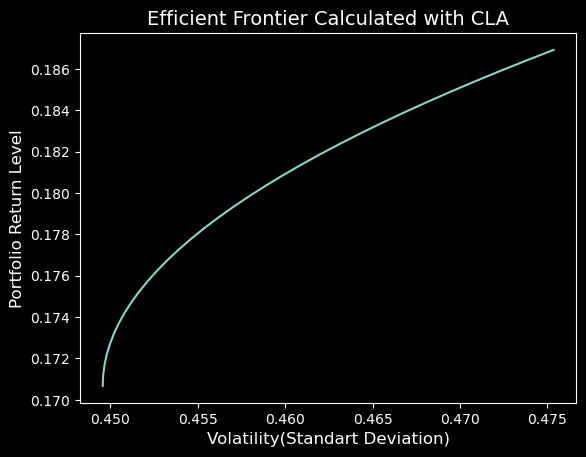

In [66]:
plt.plot(volatility,return_level)
plt.xlabel("Volatility(Standart Deviation)", fontsize=12)
plt.ylabel("Portfolio Return Level", fontsize=12)
plt.title("Efficient Frontier Calculated with CLA", fontsize=14)

In [67]:
import cvxpy as cp

In [68]:
n = 4 # amount of stocks

In [69]:
risk_sigma = covariance_matrix_pandas.values # numpy array for cvxpy

In [70]:
mean_returns_mu = expected_retuns.values

In [71]:
risk_sigma

array([[0.5362144 , 0.30504484, 0.21799341, 0.26978429],
       [0.30504484, 0.49199339, 0.25862526, 0.21831004],
       [0.21799341, 0.25862526, 0.21768565, 0.17093661],
       [0.26978429, 0.21831004, 0.17093661, 0.26431533]])

In [72]:
n = len(mean_returns_mu) #number of assets, we know its for but for automation

In [73]:
asset_vols = np.sqrt(risk_sigma.diagonal())

## Creating Efficient Frontier with cvxpy

#### Setting cvxpy variables

note:
quadratic form: $w^T \Sigma w$ (sigma being risk/ covariance matrix)_

In [74]:
weights_cvxpy = cp.Variable(n) # weights vector with size

In [75]:
portfolio_variance_cvxpy = cp.quad_form(weights_cvxpy, risk_sigma)
portfolio_return_cvxpy = mean_returns_mu @ weights_cvxpy

#### Minimum Variance Portfolio

min $w^T \Sigma w$

s.t.
*  $w^1 = 1$
* $w >= 0$

In [76]:
constraints = [

    cp.sum(weights_cvxpy) == 1, #total weights is 1
    weights_cvxpy >= 0 #a single weight cant be negative

]

In [77]:
problem = cp.Problem(cp.Minimize(portfolio_variance_cvxpy), constraints)

In [78]:
problem.solve()

np.float64(0.20208936489037932)

In [79]:
w_minimum_variance = [float('%0.4f' % v) for v in weights_cvxpy.value] #transofmring
minimum_variance_portfolio_variance = portfolio_variance_cvxpy.value



In [80]:
w_minimum_variance

[0.0, -0.0, 0.6664, 0.3336]

#### Max Return Portfolio

In [81]:
problem = cp.Problem(cp.Maximize(portfolio_return_cvxpy), constraints)
#constraints the same
problem.solve()

np.float64(0.18691193668141579)

In [82]:
w_maximum_return = [float('%0.4f' % v) for v in weights_cvxpy.value] #transofmring
max_return_variance = portfolio_variance_cvxpy.value

In [83]:
w_maximum_return

[0.0, 0.0, 1.0, 0.0]

#### Efficient Frontier Calculation with Brute Force / CVXPY:


PyPortfolioOpt comes with an implementation of the Critical Line Algorithm (CLA) of Harry Markowitz, developed at a time (1950s) when computers were not fast enough to brute-force portfolio optimizations.
<small>
---

##### Efficient Frontier Calculation with CLA

$$
\min z = \sigma_p^2 - \lambda E(R_p)
$$

Instead of fixing a target return or volatility, you combine both into a single objective controlled by $\lambda$.

##### Interpretation of Terms

- $\sigma_p^2$ — minimize risk
- $\lambda E(R_p)$ — reward return

$\lambda$ controls the tradeoff between risk and return.

##### How $\lambda$ Traces the Efficient Frontier

- $\lambda = 0$ → Only minimizes risk → minimum variance portfolio
- $\lambda \to \infty$ → Only maximizes return → maximum return portfolio
- $\lambda$ in between → Each value gives a different point on the efficient frontier


Instead of solving many independent optimization problems, CLA constructs the efficient frontier **analytically and sequentially** by identifying key transition points (corner portfolios).

##### Algorithm Steps

- Start at the **maximum return portfolio** (all weight in the highest-return asset).
- This is the first **corner portfolio**.

- Split assets into two sets:
  - **Free set** → assets whose weights can change
  - **Bounded set** → assets at their limits (e.g., weight = 0)

- Solve for optimal weights of the free set (given current constraints).

- Gradually adjust $\lambda$ and track how weights evolve.

- Detect the next **turning point**, where:
  - a free asset hits a bound (enters bounded set), or
  - a bounded asset becomes free

- Update the sets (free ↔ bounded).

- This produces a new **corner portfolio**.

- Repeat until all assets have entered/left the active set and the full frontier is traced.

</small>

- We create 200 evenly spaced volatility levels between the lowest achievable risk and the risk of the maximum-return portfolio.
- For each volatility level (will be represented with vol_limit), we solve for the portfolio weights that deliver the highest possible return without exceeding that risk budget. $portfolio\_variance\_cvxpy <= vol\_limit$

In [84]:
variance_levels = np.linspace(minimum_variance_portfolio_variance, max_return_variance, 200)

In [85]:
volatility_levels = np.sqrt(variance_levels)

In [86]:
print(minimum_variance_portfolio_variance)
print(max_return_variance)
print(variance_levels)


0.20208936489037932
0.217685653179823
[0.20208936 0.20216774 0.20224611 0.20232448 0.20240286 0.20248123
 0.2025596  0.20263798 0.20271635 0.20279472 0.2028731  0.20295147
 0.20302984 0.20310822 0.20318659 0.20326496 0.20334334 0.20342171
 0.20350008 0.20357846 0.20365683 0.2037352  0.20381358 0.20389195
 0.20397032 0.2040487  0.20412707 0.20420544 0.20428382 0.20436219
 0.20444056 0.20451894 0.20459731 0.20467568 0.20475406 0.20483243
 0.2049108  0.20498918 0.20506755 0.20514592 0.2052243  0.20530267
 0.20538104 0.20545942 0.20553779 0.20561616 0.20569454 0.20577291
 0.20585128 0.20592966 0.20600803 0.2060864  0.20616478 0.20624315
 0.20632152 0.2063999  0.20647827 0.20655664 0.20663502 0.20671339
 0.20679176 0.20687014 0.20694851 0.20702688 0.20710526 0.20718363
 0.207262   0.20734038 0.20741875 0.20749712 0.2075755  0.20765387
 0.20773224 0.20781062 0.20788899 0.20796736 0.20804574 0.20812411
 0.20820248 0.20828086 0.20835923 0.2084376  0.20851598 0.20859435
 0.20867272 0.2087511  0

In [87]:
# Definining problem abstractly:
vol_limit = cp.Parameter(nonneg=True)

constraints = [
    cp.sum(weights_cvxpy) == 1,
    weights_cvxpy >= 0,
    portfolio_variance_cvxpy <= vol_limit   # new constraint: vol <= vol_limit parameter
]

problem = cp.Problem(cp.Maximize(portfolio_return_cvxpy), constraints)



In [88]:
def solve_for_level(level):
    vol_limit.value = level #setting abstract optimization variable with real one
    result = problem.solve()
    weights_transformed = [float('%0.4f' % v) for v in weights_cvxpy.value]
    return (weights_transformed, np.sqrt(portfolio_variance_cvxpy.value), result)
    #squareroot of variance to get portfolio standart deviation instead variance

def solve_for_all_levels(variance_levels):
    """

    :return:
         tuple: Three dicts keyed by variance level —
            - weights_dict:            variance_level → optimal weights
            - portfolio_volatility_dict: variance_level → portfolio volatility (σ)
            - portfolio_returns_dict:  variance_level → maximum portfolio return
    """
    weights_dict = {}
    portfolio_volatility_dict = {}
    portfolio_returns_dict = {}


    for level in variance_levels:
        result = solve_for_level(level)
        weights_dict[level] = result[0]
        portfolio_volatility_dict[level] = result[1]
        portfolio_returns_dict[level] = result[2]

    return weights_dict, portfolio_volatility_dict, portfolio_returns_dict



In [89]:

weights_dict, portfolio_volatility_dict, portfolio_returns_dict = solve_for_all_levels(variance_levels)


Text(0.5, 1.0, 'Efficient Frontier Calculated with CVXPY')

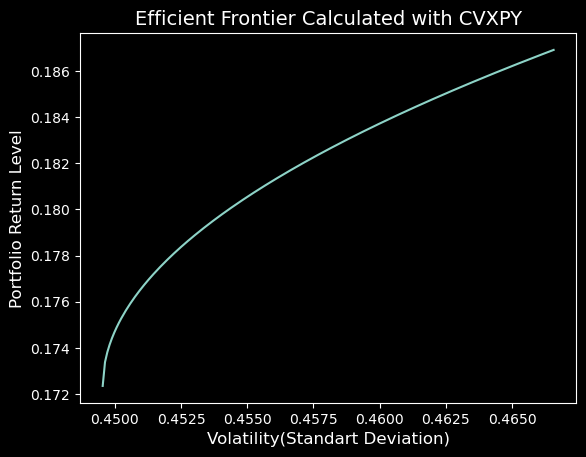

In [39]:
plt.plot(volatility_levels,portfolio_returns_dict.values())
plt.xlabel("Volatility(Standart Deviation)", fontsize=12)
plt.ylabel("Portfolio Return Level", fontsize=12)
plt.title("Efficient Frontier Calculated with CVXPY", fontsize=14)

In [107]:
def plot_current_result(volatility_levels, portfolio_returns_dict, weights_dict, tickers, title, save_path=None):

    fig, ax = plt.subplots(figsize=(14, 8))

    for spine in ax.spines.values():
        spine.set_edgecolor("white")
        spine.set_linewidth(1.5)

    ax.plot(volatility_levels, portfolio_returns_dict.values(),
            color="cyan", linewidth=2, label="Efficient Frontier")

    step = 20
    mid_vol = (min(volatility_levels) + max(volatility_levels)) / 2

    for i, (vol, weights) in enumerate(zip(volatility_levels, weights_dict.values())):
        if i % step == 0:
            ret = list(portfolio_returns_dict.values())[i]
            label = " | ".join([f"{t}: {w:.0%}" for t, w in zip(tickers, weights)])

            ax.scatter(vol, ret, color="red", zorder=5, s=30)

            ha, xtext = ("left", 5) if vol < mid_vol else ("right", -5)
            ax.annotate(label, xy=(vol, ret), fontsize=6, alpha=0.8,
                        color="white", ha=ha, xytext=(xtext, 4),
                        textcoords="offset points")

    ax.set_xlabel("Volatility (Standard Deviation)", fontsize=12)
    ax.set_ylabel("Portfolio Return Level", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return fig

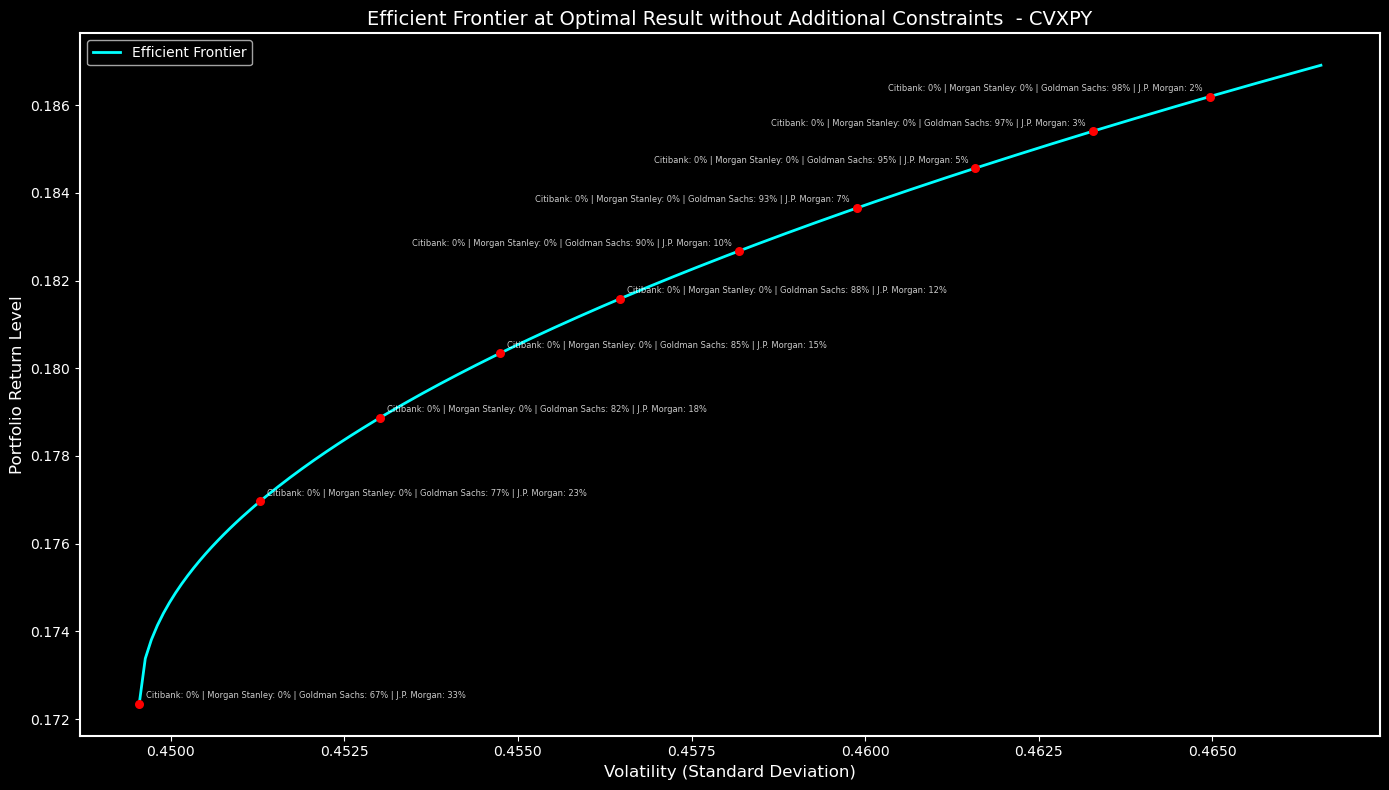

In [108]:
figure_optimal_result = plot_current_result(volatility_levels, portfolio_returns_dict, weights_dict, general_portfolio.columns, title="Efficient Frontier at Optimal Result without Additional Constraints  - CVXPY")

# Adding additional constraints for optimization

## Example 1:
Minimum: %40 in any single asset

In [128]:
constraints = [

    cp.sum(weights_cvxpy) == 1,
    weights_cvxpy >= 0,
    weights_cvxpy <= 0.40,


]
problem = cp.Problem(cp.Minimize(portfolio_variance_cvxpy), constraints)
problem.solve()

w_minimum_variance = [float('%0.4f' % v) for v in weights_cvxpy.value]  #transofmring
minimum_variance_portfolio_variance = portfolio_variance_cvxpy.value

w_minimum_variance

[0.0791, 0.1209, 0.4, 0.4]

In [111]:
problem = cp.Problem(cp.Maximize(portfolio_return_cvxpy), constraints)
#constraints the same
problem.solve()
w_maximum_return = [float('%0.4f' % v) for v in weights_cvxpy.value]  #transofmring
max_return_variance = portfolio_variance_cvxpy.value
w_maximum_return

[0.0, 0.2, 0.4, 0.4]

In [112]:
variance_levels = np.linspace(minimum_variance_portfolio_variance, max_return_variance, 200)


In [121]:
# Definining problem abstractly:
vol_limit = cp.Parameter(nonneg=True)

constraints = [
    cp.sum(weights_cvxpy) == 1,
    weights_cvxpy >= 0,
    weights_cvxpy <= 0.40,
    portfolio_variance_cvxpy <= vol_limit   # new constraint: vol <= vol_limit parameter
]

problem = cp.Problem(cp.Maximize(portfolio_return_cvxpy), constraints)

In [122]:
weights_dict, portfolio_volatility_dict, portfolio_returns_dict = solve_for_all_levels(variance_levels)


In [123]:
weights_dict

{np.float64(0.22519639509121087): [0.0791, 0.1209, 0.4, 0.4],
 np.float64(0.22520952504294406): [0.0734, 0.1266, 0.4, 0.4],
 np.float64(0.22522265499467725): [0.0711, 0.1289, 0.4, 0.4],
 np.float64(0.22523578494641044): [0.0693, 0.1307, 0.4, 0.4],
 np.float64(0.22524891489814367): [0.0678, 0.1322, 0.4, 0.4],
 np.float64(0.22526204484987686): [0.0665, 0.1335, 0.4, 0.4],
 np.float64(0.22527517480161005): [0.0653, 0.1347, 0.4, 0.4],
 np.float64(0.22528830475334324): [0.0642, 0.1358, 0.4, 0.4],
 np.float64(0.22530143470507644): [0.0632, 0.1368, 0.4, 0.4],
 np.float64(0.22531456465680963): [0.0622, 0.1378, 0.4, 0.4],
 np.float64(0.22532769460854282): [0.0613, 0.1387, 0.4, 0.4],
 np.float64(0.22534082456027604): [0.0605, 0.1395, 0.4, 0.4],
 np.float64(0.22535395451200924): [0.0596, 0.1404, 0.4, 0.4],
 np.float64(0.22536708446374243): [0.0588, 0.1412, 0.4, 0.4],
 np.float64(0.22538021441547562): [0.0581, 0.1419, 0.4, 0.4],
 np.float64(0.22539334436720881): [0.0573, 0.1427, 0.4, 0.4],
 np.floa

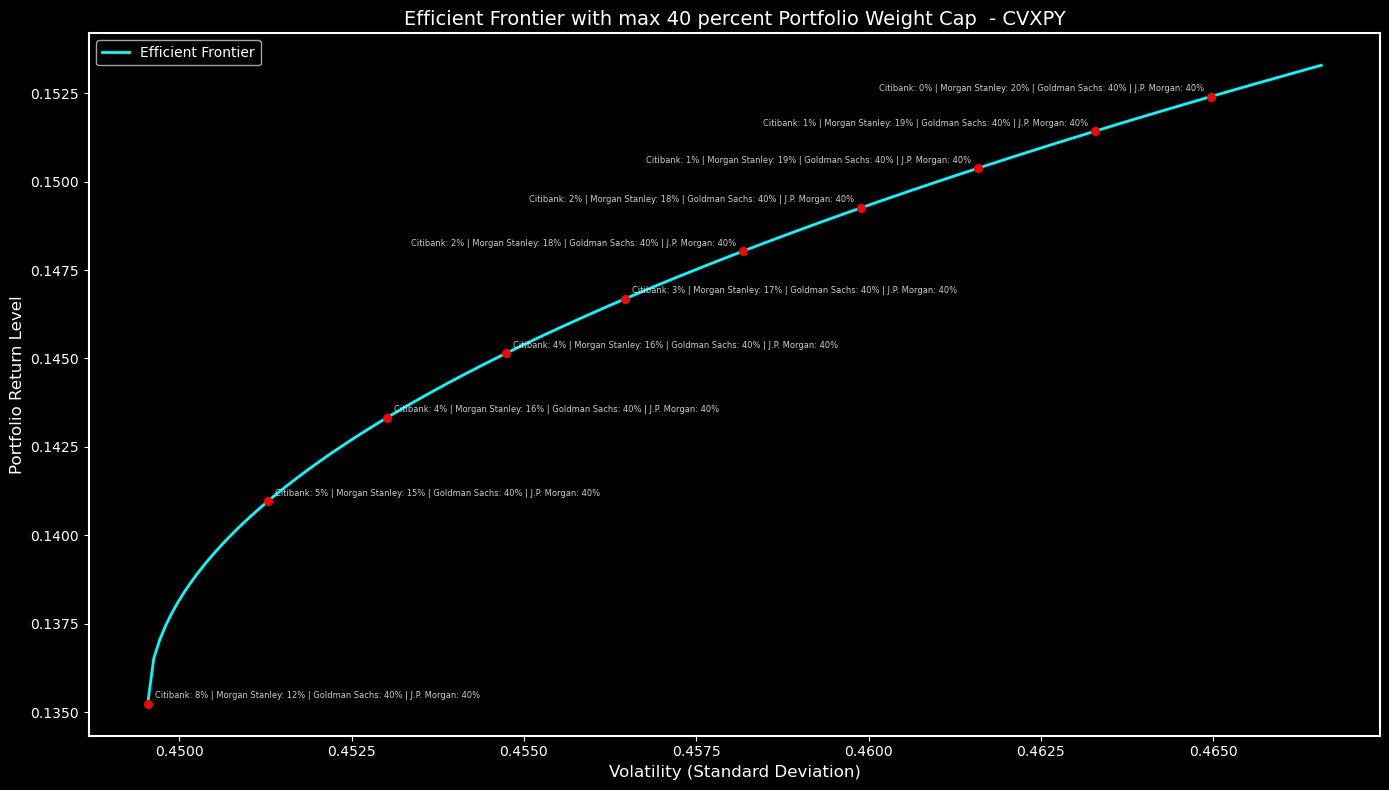

In [124]:
figure_constrained_result = plot_current_result(volatility_levels, portfolio_returns_dict, weights_dict, general_portfolio.columns, title="Efficient Frontier with max 40 percent Portfolio Weight Cap  - CVXPY")


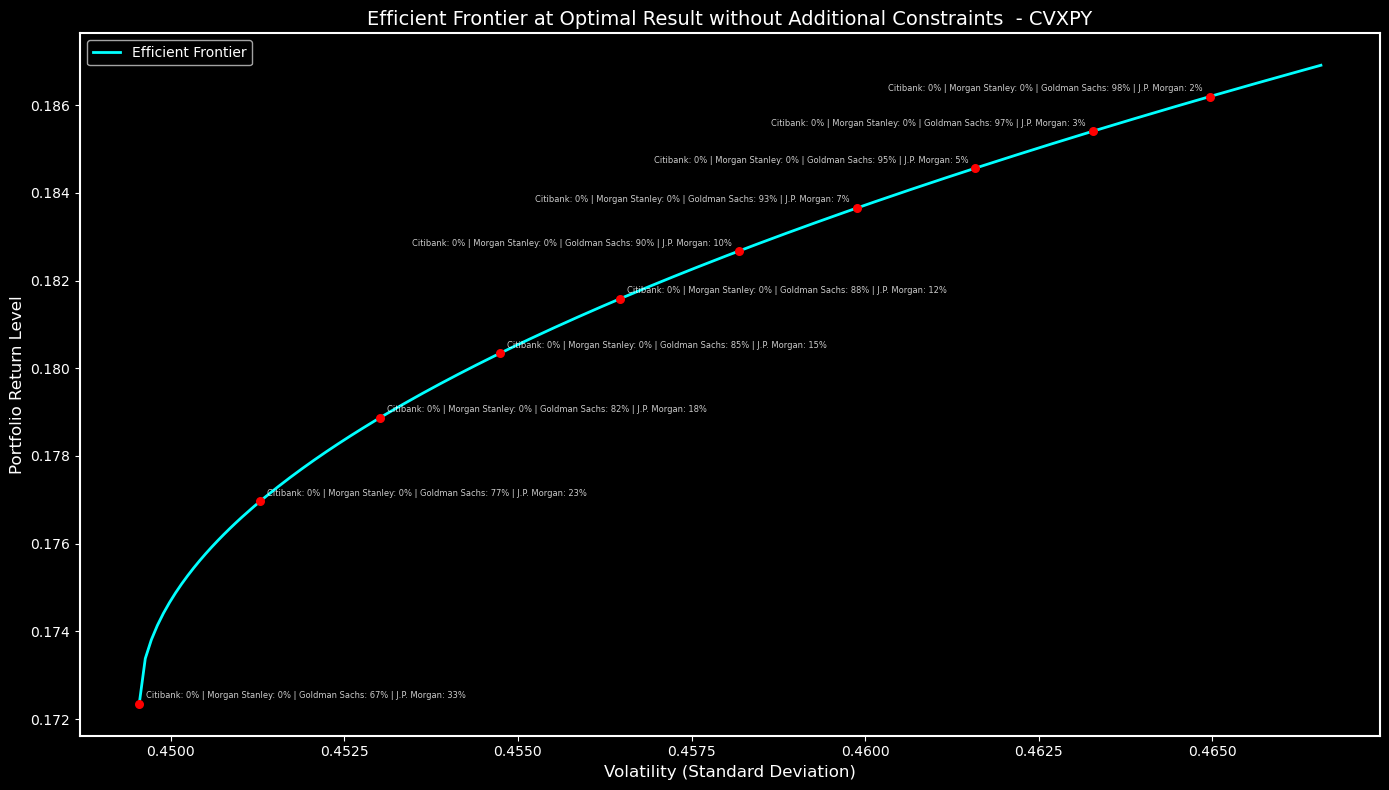

In [125]:
figure_optimal_result